📥 Fetching data for AAPL...


[*********************100%***********************]  1 of 1 completed


✅ Got 1257 rows of data from 2020-01-02 to 2024-12-30
✅ Features created. Dataset has 1237 rows and 17 columns.

📋 Sample Data (last 5 rows):
Price            Close    Return         MA5        MA20        RSI  Volume_Change  Volatility  Target
Date                                                                                                  
2024-12-20  253.107376  1.881588  250.004303  242.432661  75.940159     142.263022    1.549545       1
2024-12-23  253.883133  0.306493  250.845715  243.695763  73.865399     -72.298236    1.505720       1
2024-12-24  256.797241  1.147815  251.784598  244.955384  76.180672     -43.134160    1.525976       1
2024-12-26  257.612732  0.317562  253.966675  246.146875  76.812098      17.225959    0.661743       0
2024-12-27  254.201385 -1.324215  255.120374  247.174263  69.300689      55.505909    1.195942       0

🎯 Target Distribution:
  UP days   (1): 659 (53.3%)
  DOWN days (0): 578 (46.7%)
📊 Chart saved as stock_analysis.png


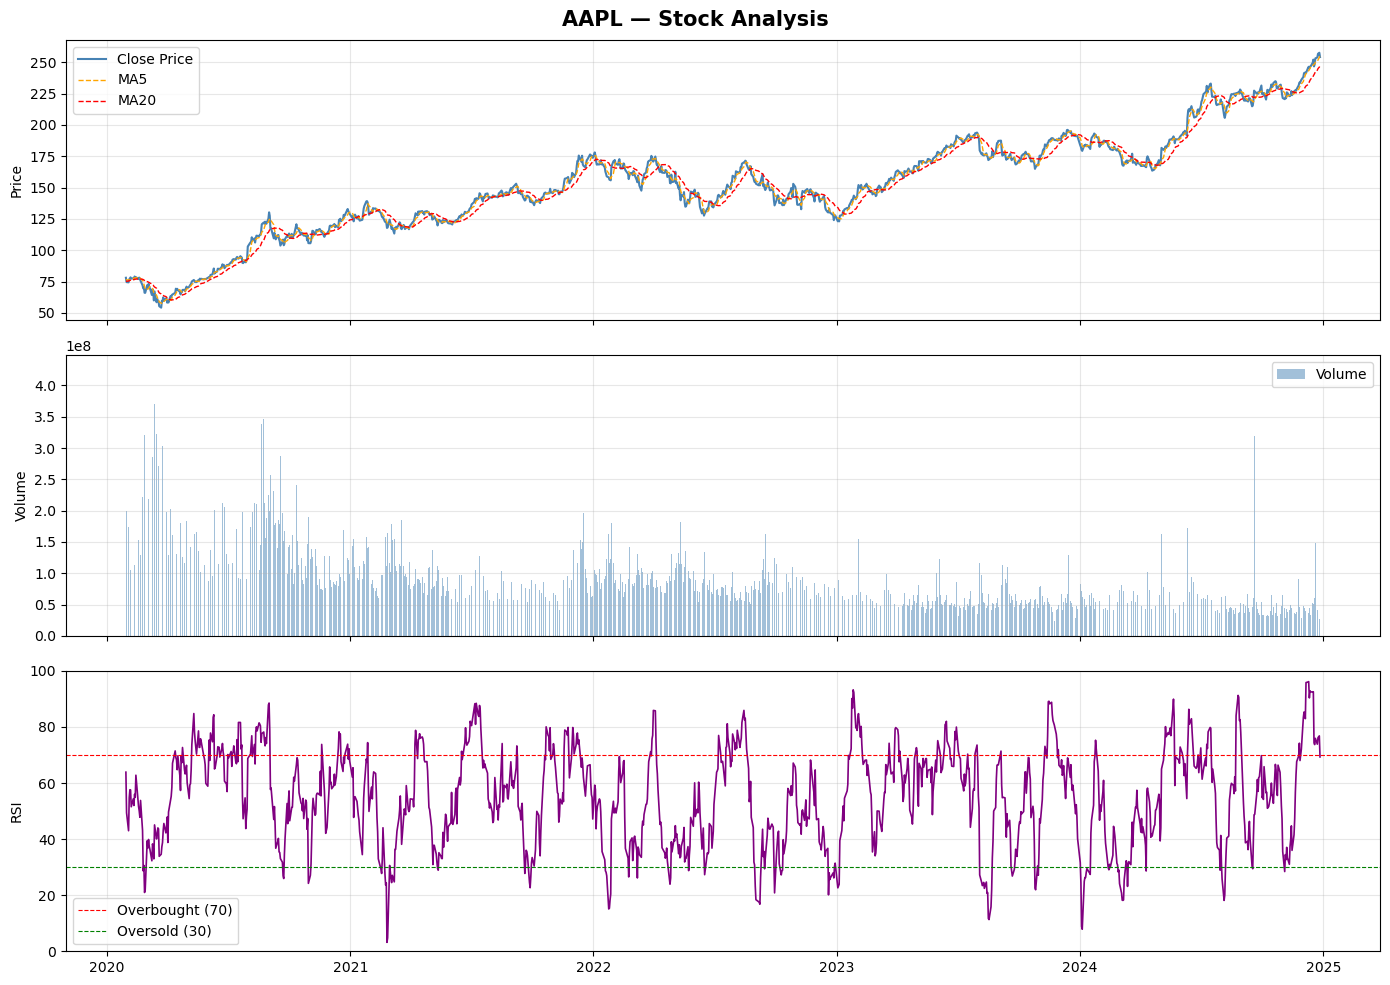


💾 Saved to stock_data_features.csv — ready for Day 3 (model training)!


In [1]:
"""
Day 1 & 2: Data Fetching + Feature Engineering
Run this file first to understand your data before building the model.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


def fetch_stock_data(ticker: str, start: str = "2020-01-01", end: str = "2024-12-31") -> pd.DataFrame:
    """Fetch historical stock data from Yahoo Finance."""
    print(f"📥 Fetching data for {ticker}...")
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)

    if df.empty:
        raise ValueError(f"No data found for ticker '{ticker}'. Check the symbol and try again.")

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    print(f"✅ Got {len(df)} rows of data from {df.index[0].date()} to {df.index[-1].date()}")
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature Engineering — turning raw price data into ML features.
    Each feature gives the model a different 'signal' about price movement.
    """
    df = df.copy()

    # --- Target Variable ---
    # 1 = price went UP next day, 0 = price went DOWN
    df['Tomorrow_Close'] = df['Close'].shift(-1)
    df['Target'] = (df['Tomorrow_Close'] > df['Close']).astype(int)

    # --- Feature 1: Daily Return ---
    # How much did the price change today (in %)?
    df['Return'] = df['Close'].pct_change() * 100

    # --- Feature 2: Moving Averages ---
    # Average closing price over last N days — smooths out noise
    df['MA5']  = df['Close'].rolling(window=5).mean()
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()

    # --- Feature 3: MA Crossover signals ---
    # When short MA > long MA, it's a bullish signal
    df['MA5_above_MA20'] = (df['MA5'] > df['MA20']).astype(int)

    # --- Feature 4: Volume Change ---
    # Unusual volume often signals big moves
    df['Volume_Change'] = df['Volume'].pct_change() * 100

    # --- Feature 5: Price vs Moving Average (gap %) ---
    # Is the price far above/below its average? (mean reversion signal)
    df['Price_vs_MA20'] = ((df['Close'] - df['MA20']) / df['MA20']) * 100

    # --- Feature 6: RSI (Relative Strength Index) ---
    # RSI > 70 = overbought (price may drop), RSI < 30 = oversold (price may rise)
    df['RSI'] = compute_rsi(df['Close'], window=14)

    # --- Feature 7: Volatility ---
    # How wildly has price swung over the last 5 days?
    df['Volatility'] = df['Return'].rolling(window=5).std()

    # --- Feature 8: High-Low Range ---
    # Big daily range = high uncertainty
    df['HL_Range'] = ((df['High'] - df['Low']) / df['Close']) * 100

    # Drop rows with NaN (from rolling calculations)
    df.dropna(inplace=True)

    print(f"✅ Features created. Dataset has {len(df)} rows and {len(df.columns)} columns.")
    return df


def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Compute RSI (Relative Strength Index)."""
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def plot_stock(df: pd.DataFrame, ticker: str):
    """Quick visualization of price + moving averages."""
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{ticker} — Stock Analysis", fontsize=15, fontweight='bold')

    # Plot 1: Price + Moving Averages
    ax1.plot(df.index, df['Close'], label='Close Price', color='steelblue', linewidth=1.5)
    ax1.plot(df.index, df['MA5'],   label='MA5',   color='orange',  linewidth=1, linestyle='--')
    ax1.plot(df.index, df['MA20'],  label='MA20',  color='red',     linewidth=1, linestyle='--')
    ax1.set_ylabel("Price")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Volume
    ax2.bar(df.index, df['Volume'], color='steelblue', alpha=0.5, label='Volume')
    ax2.set_ylabel("Volume")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: RSI
    ax3.plot(df.index, df['RSI'], color='purple', linewidth=1.2)
    ax3.axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
    ax3.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
    ax3.set_ylabel("RSI")
    ax3.set_ylim(0, 100)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("stock_analysis.png", dpi=120)
    print("📊 Chart saved as stock_analysis.png")
    plt.show()


def summarize(df: pd.DataFrame):
    """Print a quick data summary."""
    features = ['Close', 'Return', 'MA5', 'MA20', 'RSI', 'Volume_Change', 'Volatility', 'Target']
    print("\n📋 Sample Data (last 5 rows):")
    print(df[features].tail().to_string())

    print(f"\n🎯 Target Distribution:")
    counts = df['Target'].value_counts()
    print(f"  UP days   (1): {counts.get(1, 0)} ({counts.get(1, 0)/len(df)*100:.1f}%)")
    print(f"  DOWN days (0): {counts.get(0, 0)} ({counts.get(0, 0)/len(df)*100:.1f}%)")


# ─── Run this file directly to test ───────────────────────────────────────────
if __name__ == "__main__":
    TICKER = "AAPL"   # Change to any ticker, e.g. "TCS.NS", "RELIANCE.NS", "TSLA"

    df = fetch_stock_data(TICKER)
    df = add_features(df)
    summarize(df)
    plot_stock(df, TICKER)

    # Save for use in model training
    df.to_csv("stock_data_features.csv")
    print("\n💾 Saved to stock_data_features.csv — ready for Day 3 (model training)!")
